In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio

pio.renderers.default="svg"

In [2]:
raw_df=pd.read_csv("Zomato chennai.csv")
raw_df.head()

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,https://www.zomato.com/chennai/yaa-mohaideen-b...,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,https://www.zomato.com/chennai/sukkubhai-biriy...,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,https://www.zomato.com/chennai/ss-hyderabad-bi...,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,https://www.zomato.com/chennai/kfc-perambur,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,https://www.zomato.com/chennai/tasty-kitchen-p...,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


In [3]:
raw_df.columns

Index(['Zomato URL', 'Name of Restaurant', 'Address', 'Location', 'Cuisine',
       'Top Dishes', 'Price for 2', 'Dining Rating', 'Dining Rating Count',
       'Delivery Rating', 'Delivery Rating Count', 'Features'],
      dtype='object')

In [4]:
raw_df.shape

(12032, 12)

In [5]:
raw_df.describe()

,Price for 2,Dining Rating,Delivery Rating
count,12032.000000,6681.000000,6181.000000
mean,397.611370,3.387756,3.805290
std,332.045938,0.558181,0.374213
min,40.000000,0.300000,0.300000
25%,200.000000,3.100000,3.600000
50%,300.000000,3.500000,3.900000
75%,450.000000,3.800000,4.000000
max,5000.000000,4.900000,4.700000


In [6]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Zomato URL             12032 non-null  object 
 1   Name of Restaurant     12032 non-null  object 
 2   Address                12032 non-null  object 
 3   Location               12032 non-null  object 
 4   Cuisine                12032 non-null  object 
 5   Top Dishes             12032 non-null  object 
 6   Price for 2            12032 non-null  float64
 7   Dining Rating          6681 non-null   float64
 8   Dining Rating Count    11812 non-null  object 
 9   Delivery Rating        6181 non-null   float64
 10  Delivery Rating Count  11812 non-null  object 
 11  Features               12032 non-null  object 
dtypes: float64(3), object(9)
memory usage: 1.1+ MB


In [7]:
raw_df.drop(['Zomato URL','Address','Dining Rating Count'],axis=1,inplace=True)
raw_df.head()

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,4.1,22400,"['Home Delivery', 'Indoor Seating']"


In [8]:
#Finding Null values
raw_df.isnull().sum()

Name of Restaurant          0
Location                    0
Cuisine                     0
Top Dishes                  0
Price for 2                 0
Dining Rating            5351
Delivery Rating          5851
Delivery Rating Count     220
Features                    0
dtype: int64

In [9]:
raw_df.fillna('NA',inplace=True)

C:\Users\Sathish\AppData\Local\Temp\ipykernel_12800\1419711990.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NA' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  raw_df.fillna('NA',inplace=True)


In [10]:
raw_df.isnull().sum()

Name of Restaurant       0
Location                 0
Cuisine                  0
Top Dishes               0
Price for 2              0
Dining Rating            0
Delivery Rating          0
Delivery Rating Count    0
Features                 0
dtype: int64

In [11]:
raw_df['Dining Rating'].value_counts()

Dining Rating
NA     5351
3.6     584
3.5     553
3.7     525
3.4     500
3.3     463
3.8     460
3.2     433
3.9     379
3.1     363
2.0     354
3.0     302
4.0     288
2.9     257
4.1     221
2.8     192
4.2     142
2.7     138
4.3     105
2.6      99
2.5      71
4.4      61
2.4      46
4.5      36
2.3      32
2.2      20
4.6      17
4.7      12
2.1      10
4.9       7
4.8       4
1.9       3
1.7       2
0.3       1
1.0       1
Name: count, dtype: int64

In [12]:
raw_df['Dining Rating'].replace(to_replace=['NA'],value=0,inplace=True)

C:\Users\Sathish\AppData\Local\Temp\ipykernel_12800\3195466092.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_df['Dining Rating'].replace(to_replace=['NA'],value=0,inplace=True)
C:\Users\Sathish\AppData\Local\Temp\ipykernel_12800\3195466092.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [13]:
raw_df['Delivery Rating'].value_counts()

Delivery Rating
NA     5851
3.9    1383
3.8     701
4.0     570
3.7     559
4.1     468
3.6     465
4.2     401
3.5     314
4.3     277
3.4     259
3.3     189
4.4     128
3.2      93
3.1      79
3.0      63
4.5      55
2.9      39
2.8      26
4.6      24
2.7      19
2.6      17
2.5       9
0.3       8
2.4       7
1.8       5
2.3       5
2.0       5
2.2       5
4.7       4
2.1       2
1.6       1
1.5       1
Name: count, dtype: int64

In [14]:
raw_df['Delivery Rating'].replace(to_replace=['NA'],value=0,inplace=True)

C:\Users\Sathish\AppData\Local\Temp\ipykernel_12800\36700658.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_df['Delivery Rating'].replace(to_replace=['NA'],value=0,inplace=True)
C:\Users\Sathish\AppData\Local\Temp\ipykernel_12800\36700658.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  

In [15]:
raw_df['Delivery Rating'].value_counts()

Delivery Rating
0.0    5851
3.9    1383
3.8     701
4.0     570
3.7     559
4.1     468
3.6     465
4.2     401
3.5     314
4.3     277
3.4     259
3.3     189
4.4     128
3.2      93
3.1      79
3.0      63
4.5      55
2.9      39
2.8      26
4.6      24
2.7      19
2.6      17
2.5       9
0.3       8
2.4       7
1.8       5
2.3       5
2.0       5
2.2       5
4.7       4
2.1       2
1.6       1
1.5       1
Name: count, dtype: int64

In [16]:
raw_df['Top Dishes'].value_counts()

Top Dishes
Invalid                                                                                                                              9641
['Biryani']                                                                                                                            30
['Coffee']                                                                                                                             14
['Chicken Biryani']                                                                                                                    12
['Pizza', ' Garlic Bread']                                                                                                             11
                                                                                                                                     ... 
['Chicken 65', ' Mutton Biryani', ' Tandoori Chicken', ' Chicken Biryani', ' Kothu Parotta', ' Brinjal Gravy', ' Paratha']              1
['Egg Noodles', ' Punja

In [17]:
raw_df['Delivery Rating Count'].replace(to_replace=['NA','Does not offer Delivery','Not enough Delivery Reviews'],value=0,inplace=True)

C:\Users\Sathish\AppData\Local\Temp\ipykernel_12800\293670212.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_df['Delivery Rating Count'].replace(to_replace=['NA','Does not offer Delivery','Not enough Delivery Reviews'],value=0,inplace=True)


In [18]:
raw_df.rename(columns={'Price for 2':'Price'},inplace=True)

In [19]:
raw_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price,Dining Rating,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...
12027,CK's Sandwiches,Porur,['Sandwich'],Invalid,350.0,0.0,0.0,0,"['Breakfast', 'Delivery Only']"
12028,CK's Sandwiches,Kolathur,['Sandwich'],Invalid,350.0,0.0,0.0,0,"['Breakfast', 'Delivery Only']"
12029,CK's Sandwiches,Anna Nagar East,['Sandwich'],Invalid,350.0,0.0,0.0,0,"['Breakfast', 'Delivery Only']"
12030,CK's Sandwiches,Ramapuram,['Sandwich'],Invalid,350.0,0.0,0.0,0,"['Breakfast', 'Delivery Only']"


In [20]:
raw_df['Price']=raw_df['Price'].astype('int64')
raw_df['Dining Rating']=raw_df['Dining Rating'].astype('float64')
raw_df['Delivery Rating']=raw_df['Delivery Rating'].astype('float64')

In [21]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name of Restaurant     12032 non-null  object 
 1   Location               12032 non-null  object 
 2   Cuisine                12032 non-null  object 
 3   Top Dishes             12032 non-null  object 
 4   Price                  12032 non-null  int64  
 5   Dining Rating          12032 non-null  float64
 6   Delivery Rating        12032 non-null  float64
 7   Delivery Rating Count  12032 non-null  object 
 8   Features               12032 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 846.1+ KB


In [22]:
#Removing the restaurant records whose Rating is 0

useless_data=(raw_df['Delivery Rating']==0.0)
raw_df[useless_data]

,Name of Restaurant,Location,Cuisine,Top Dishes,Price,Dining Rating,Delivery Rating,Delivery Rating Count,Features
15,Welcome Hotel,Purasavakkam,"['South Indian', ' Desserts', ' Beverages']","['Pongal', ' Podi Dosa', ' Idli Sambar', ' Vad...",300,4.5,0.0,0,"['Breakfast', 'Vegetarian Only', 'Indoor Seati..."
18,Wire Room Bar & Kitchen,"Phoenix Market City, Velachery","['Continental', ' Asian']","['Cocktails', ' Salad', ' Beer', ' Tikka', ' P...",2000,4.1,0.0,0,"['Full Bar Available', 'Mall Parking', 'Dance ..."
23,BFF 2.0,RA Puram,"['North Indian', ' Continental', ' Italian']","['Crispy Chicken', ' Cocktails', ' Pizza', ' N...",1500,4.2,0.0,0,"['Full Bar Available', 'Indoor Seating', 'Nigh..."
85,Bazaar - All Day Diner - Grand by GRT Hotels,Grand by GRT Hotels,"['North Indian', ' South Indian', ' Continenta...","['Pizza', ' Pasta', ' Fish', ' Chaat', ' Momos...",2500,4.4,0.0,0,"['Breakfast', 'Home Delivery', 'Serves Alcohol..."
89,Coal Barbecues,Velachery,"['North Indian', ' Chinese']","['Chicken Honey', ' Fish', ' Prawn', ' Waffles...",1400,4.4,0.0,0,"['Indoor Seating', 'Buffet', 'Table reservatio..."
...,...,...,...,...,...,...,...,...,...
12027,CK's Sandwiches,Porur,['Sandwich'],Invalid,350,0.0,0.0,0,"['Breakfast', 'Delivery Only']"
12028,CK's Sandwiches,Kolathur,['Sandwich'],Invalid,350,0.0,0.0,0,"['Breakfast', 'Delivery Only']"
12029,CK's Sandwiches,Anna Nagar East,['Sandwich'],Invalid,350,0.0,0.0,0,"['Breakfast', 'Delivery Only']"
12030,CK's Sandwiches,Ramapuram,['Sandwich'],Invalid,350,0.0,0.0,0,"['Breakfast', 'Delivery Only']"


In [23]:
raw_df=raw_df[~useless_data]

In [24]:
raw_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price,Dining Rating,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500,4.3,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000,4.4,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500,4.3,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500,4.0,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450,4.2,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...
11901,Dhabba On Wheels,Okkiyampet,['North Indian'],Invalid,500,0.0,3.0,54,"['Home Delivery', 'Indoor Seating']"
11914,Sandwich Sisters,Velachery,['Sandwich'],Invalid,200,0.0,3.6,75,"['Home Delivery', 'Free Parking']"
11953,The Sandwich Box,Navallur,"['Sandwich', ' Fast Food', ' Beverages']",Invalid,300,0.0,3.9,21,"['Home Delivery', 'Indoor Seating']"
11959,The Shangai Story,Madipakkam,['Chinese'],Invalid,350,0.0,2.9,17,['Delivery Only']


In [25]:
raw_df['Location'].value_counts()

Location
Velachery                                                   214
Porur                                                       209
Anna Nagar East                                             192
T. Nagar                                                    166
Ambattur                                                    162
                                                           ... 
Hotel Sudhara, T. Nagar                                       1
Eat And Pack, Ambattur                                        1
RMZ Millenia Business Park, Old Mahabalipuram Road (OMR)      1
Spectrum The Grand Venus Mall, Perambur                       1
Hotel Chennai Deluxe, Koyambedu                               1
Name: count, Length: 162, dtype: int64

In [26]:
raw_df['Location']=raw_df['Location'].str.replace('[a-xA-Z].+,','',regex=True)

C:\Users\Sathish\AppData\Local\Temp\ipykernel_12800\422629665.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df['Location']=raw_df['Location'].str.replace('[a-xA-Z].+,','',regex=True)


In [27]:
raw_df['Location'].value_counts()

Location
Velachery                        214
Porur                            209
Anna Nagar East                  192
T. Nagar                         166
Ambattur                         162
                                ... 
Muttukadu                          1
 Ambattur                          1
 Old Mahabalipuram Road (OMR)      1
 Perambur                          1
 Koyambedu                         1
Name: count, Length: 148, dtype: int64

In [28]:
raw_df['Cuisine']=raw_df['Cuisine'].str.replace('[','',regex=False).str.replace(']','',regex=False).str.replace("'",'',regex=False)

C:\Users\Sathish\AppData\Local\Temp\ipykernel_12800\1886084618.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df['Cuisine']=raw_df['Cuisine'].str.replace('[','',regex=False).str.replace(']','',regex=False).str.replace("'",'',regex=False)


In [29]:
raw_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price,Dining Rating,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,Biryani,"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500,4.3,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"Biryani, North Indian, Mughlai, Desserts, ...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000,4.4,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"Biryani, North Indian, Chinese, Arabian","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500,4.3,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"Burger, Fast Food, Finger Food, Beverages",['Zinger Burger'],500,4.0,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"Chinese, Biryani, North Indian, Chettinad, ...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450,4.2,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...
11901,Dhabba On Wheels,Okkiyampet,North Indian,Invalid,500,0.0,3.0,54,"['Home Delivery', 'Indoor Seating']"
11914,Sandwich Sisters,Velachery,Sandwich,Invalid,200,0.0,3.6,75,"['Home Delivery', 'Free Parking']"
11953,The Sandwich Box,Navallur,"Sandwich, Fast Food, Beverages",Invalid,300,0.0,3.9,21,"['Home Delivery', 'Indoor Seating']"
11959,The Shangai Story,Madipakkam,Chinese,Invalid,350,0.0,2.9,17,['Delivery Only']


In [30]:
raw_df['Cuisine']=raw_df['Cuisine'].str.strip("[]")
raw_df['Top Dishes']=raw_df['Top Dishes'].str.strip("[]").replace("'",'',regex=True)
raw_df['Features']=raw_df['Features'].str.strip("[]''").replace("'",'',regex=True)

#Strip is used to remove the character beginning and end of the string but replace is used to everywwhere in the string

C:\Users\Sathish\AppData\Local\Temp\ipykernel_12800\1445575129.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df['Cuisine']=raw_df['Cuisine'].str.strip("[]")
C:\Users\Sathish\AppData\Local\Temp\ipykernel_12800\1445575129.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df['Top Dishes']=raw_df['Top Dishes'].str.strip("[]").replace("'",'',regex=True)
C:\Users\Sathish\AppData\Local\Temp\ipykernel_12800\1445575129.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fr

In [31]:
raw_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price,Dining Rating,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,Biryani,"Bread Halwa, Chicken 65, Mutton Biryani, Ch...",500,4.3,4.3,9306,"Home Delivery, Indoor Seating"
1,Sukkubhai Biriyani,Alandur,"Biryani, North Indian, Mughlai, Desserts, ...","Beef Biryani, Beef Fry, Paratha, Paya, Bri...",1000,4.4,4.1,39200,"Home Delivery, Free Parking, Table booking rec..."
2,SS Hyderabad Biryani,Kodambakkam,"Biryani, North Indian, Chinese, Arabian","Brinjal Curry, Tandoori Chicken, Chicken Gri...",500,4.3,4.4,10500,"Home Delivery, Indoor Seating"
3,KFC,Perambur,"Burger, Fast Food, Finger Food, Beverages",Zinger Burger,500,4.0,4.0,11200,"Home Delivery, Free Parking, Card Upon Deliver..."
4,Tasty Kitchen,Perambur,"Chinese, Biryani, North Indian, Chettinad, ...","Mutton Biryani, Chicken Rice, Tomato Rice, ...",450,4.2,4.1,22400,"Home Delivery, Indoor Seating"
...,...,...,...,...,...,...,...,...,...
11901,Dhabba On Wheels,Okkiyampet,North Indian,Invalid,500,0.0,3.0,54,"Home Delivery, Indoor Seating"
11914,Sandwich Sisters,Velachery,Sandwich,Invalid,200,0.0,3.6,75,"Home Delivery, Free Parking"
11953,The Sandwich Box,Navallur,"Sandwich, Fast Food, Beverages",Invalid,300,0.0,3.9,21,"Home Delivery, Indoor Seating"
11959,The Shangai Story,Madipakkam,Chinese,Invalid,350,0.0,2.9,17,Delivery Only


In [32]:
raw_df[raw_df.duplicated()]

,Name of Restaurant,Location,Cuisine,Top Dishes,Price,Dining Rating,Delivery Rating,Delivery Rating Count,Features


In [33]:
zomato_df=raw_df.copy()

In [34]:
zomato_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price,Dining Rating,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,Biryani,"Bread Halwa, Chicken 65, Mutton Biryani, Ch...",500,4.3,4.3,9306,"Home Delivery, Indoor Seating"
1,Sukkubhai Biriyani,Alandur,"Biryani, North Indian, Mughlai, Desserts, ...","Beef Biryani, Beef Fry, Paratha, Paya, Bri...",1000,4.4,4.1,39200,"Home Delivery, Free Parking, Table booking rec..."
2,SS Hyderabad Biryani,Kodambakkam,"Biryani, North Indian, Chinese, Arabian","Brinjal Curry, Tandoori Chicken, Chicken Gri...",500,4.3,4.4,10500,"Home Delivery, Indoor Seating"
3,KFC,Perambur,"Burger, Fast Food, Finger Food, Beverages",Zinger Burger,500,4.0,4.0,11200,"Home Delivery, Free Parking, Card Upon Deliver..."
4,Tasty Kitchen,Perambur,"Chinese, Biryani, North Indian, Chettinad, ...","Mutton Biryani, Chicken Rice, Tomato Rice, ...",450,4.2,4.1,22400,"Home Delivery, Indoor Seating"
...,...,...,...,...,...,...,...,...,...
11901,Dhabba On Wheels,Okkiyampet,North Indian,Invalid,500,0.0,3.0,54,"Home Delivery, Indoor Seating"
11914,Sandwich Sisters,Velachery,Sandwich,Invalid,200,0.0,3.6,75,"Home Delivery, Free Parking"
11953,The Sandwich Box,Navallur,"Sandwich, Fast Food, Beverages",Invalid,300,0.0,3.9,21,"Home Delivery, Indoor Seating"
11959,The Shangai Story,Madipakkam,Chinese,Invalid,350,0.0,2.9,17,Delivery Only


In [35]:
zomato_df.head()

,Name of Restaurant,Location,Cuisine,Top Dishes,Price,Dining Rating,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,Biryani,"Bread Halwa, Chicken 65, Mutton Biryani, Ch...",500,4.3,4.3,9306,"Home Delivery, Indoor Seating"
1,Sukkubhai Biriyani,Alandur,"Biryani, North Indian, Mughlai, Desserts, ...","Beef Biryani, Beef Fry, Paratha, Paya, Bri...",1000,4.4,4.1,39200,"Home Delivery, Free Parking, Table booking rec..."
2,SS Hyderabad Biryani,Kodambakkam,"Biryani, North Indian, Chinese, Arabian","Brinjal Curry, Tandoori Chicken, Chicken Gri...",500,4.3,4.4,10500,"Home Delivery, Indoor Seating"
3,KFC,Perambur,"Burger, Fast Food, Finger Food, Beverages",Zinger Burger,500,4.0,4.0,11200,"Home Delivery, Free Parking, Card Upon Deliver..."
4,Tasty Kitchen,Perambur,"Chinese, Biryani, North Indian, Chettinad, ...","Mutton Biryani, Chicken Rice, Tomato Rice, ...",450,4.2,4.1,22400,"Home Delivery, Indoor Seating"


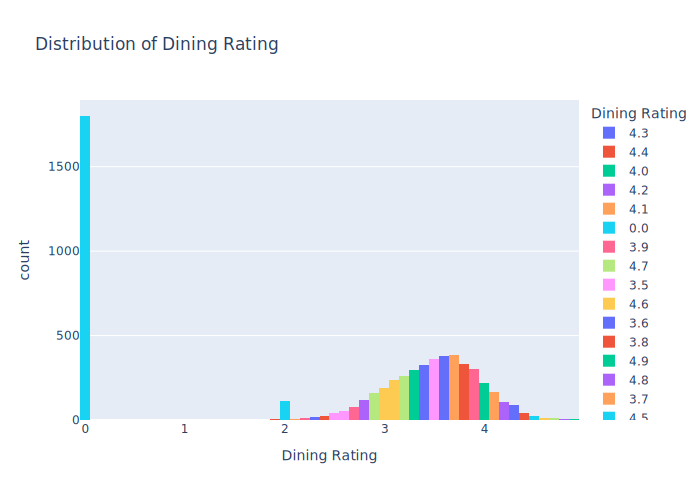

In [36]:
fig=px.histogram(zomato_df,x='Dining Rating',color='Dining Rating',title='Distribution of Dining Rating')
fig.show()

In [37]:
delivery_rating_df=zomato_df["Delivery Rating"].value_counts().reset_index()
delivery_rating_df
def category(rating):
    if rating >= 4.5:
        return "Very Good"
    elif rating > 4.0:
        return "Good"
    elif rating > 3.0:
        return "Average"
    else:
        return "Poor"
delivery_rating_df["Rating Type"] = delivery_rating_df["Delivery Rating"].apply(category)
delivery_rating_df

,Delivery Rating,count,Rating Type
0,3.9,1383,Average
1,3.8,701,Average
2,4.0,570,Average
3,3.7,559,Average
4,4.1,468,Good
5,3.6,465,Average
6,4.2,401,Good
7,3.5,314,Average
8,4.3,277,Good
9,3.4,259,Average


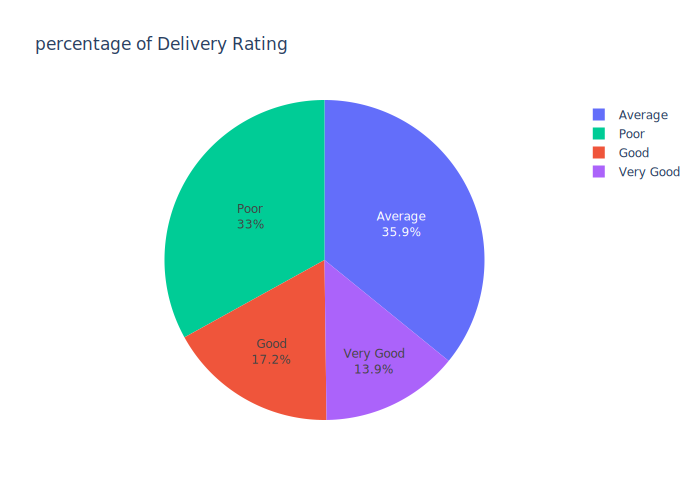

In [38]:
fig=px.pie(delivery_rating_df,names='Rating Type',values='Delivery Rating',color='Rating Type',title='percentage of Delivery Rating').update_traces(textposition='inside',textinfo="percent+label")
fig.show()

In [39]:
zomato_df['Cuisine']

0                                                  Biryani
1        Biryani,  North Indian,  Mughlai,  Desserts,  ...
2               Biryani,  North Indian,  Chinese,  Arabian
3             Burger,  Fast Food,  Finger Food,  Beverages
4        Chinese,  Biryani,  North Indian,  Chettinad, ...
                               ...                        
11901                                         North Indian
11914                                             Sandwich
11953                     Sandwich,  Fast Food,  Beverages
11959                                              Chinese
11960                                              Chinese
Name: Cuisine, Length: 6181, dtype: object

In [40]:
chinese_rest_df=zomato_df[zomato_df['Cuisine'].str.contains('Chinese')]
chinese_rest_df.sort_values(by='Name of Restaurant').head(10)

,Name of Restaurant,Location,Cuisine,Top Dishes,Price,Dining Rating,Delivery Rating,Delivery Rating Count,Features
7183,1 Point 2 Devi Mess,Porur,"North Indian, Chinese, Biryani",Invalid,300,0.0,3.6,104,"Home Delivery, Indoor Seating"
208,27 Culinary Street,Mylapore,"Chinese, North Indian, South Indian","Chocolate Pani Puri, Momos, Pasta, Prawn, ...",800,4.3,3.9,67,"Home Delivery, Valet Parking Available, Table ..."
6384,36 Spices Fast Food,Kolathur,"Chinese, South Indian",Invalid,350,0.0,3.9,22,"Home Delivery, Indoor Seating"
2104,49 & 99,Anna Nagar West,"Fast Food, Chinese, South Indian, North Indian",Invalid,400,3.4,4.0,181,"Home Delivery, Indoor Seating"
7265,5 Star Biryani,Valasaravakkam,"North Indian, South Indian, Chinese, Beverages",Invalid,500,0.0,3.1,34,Delivery Only
2950,5 Star Chef Kitchen,Potheri,"North Indian, Chinese, Biryani",Invalid,400,3.9,3.8,322,"Home Delivery, Indoor Seating"
2126,5araipetty Classic,Selaiyur,"South Indian, Chettinad, Chinese, North Ind...",Invalid,350,3.5,3.6,800,"Breakfast, Home Delivery, Indoor Seating, Outd..."
2841,90s Kids Food,Ramapuram,"South Indian, Chinese, Fast Food",Invalid,250,3.7,3.9,25,"Breakfast, Home Delivery, Indoor Seating"
1368,96 Restaurant,Poonamalle,"Chinese, Chettinad, North Indian",Invalid,500,3.0,3.6,6288,"Home Delivery, Indoor Seating"
1734,99 Parotta Verities,Washermenpet,"Chinese, Chettinad, South Indian",Invalid,400,0.0,3.7,1384,Home Delivery


In [41]:
home_del_df=zomato_df[zomato_df['Features']=='Home Delivery']
home_del_df.sort_values(by='Delivery Rating',ascending=False).head(2)

,Name of Restaurant,Location,Cuisine,Top Dishes,Price,Dining Rating,Delivery Rating,Delivery Rating Count,Features
3301,Mo Thickshake And Snackers,Vadapalani,Beverages,Invalid,300,0.0,4.7,590,Home Delivery
3158,Biryani In A Box,Egmore,"Biryani, Fast Food",Invalid,400,0.0,4.6,78,Home Delivery


In [42]:
rating_df=zomato_df[zomato_df['Delivery Rating']>4.5]
rating_df.head()

,Name of Restaurant,Location,Cuisine,Top Dishes,Price,Dining Rating,Delivery Rating,Delivery Rating Count,Features
92,Fruit Shop On Greams Road,Thousand Lights,"Beverages, Fast Food, Healthy Food, Juices","Fruit Juices, Sandwich, Mint Lime Cooler, T...",350,4.5,4.6,1699,"Home Delivery, Vegetarian Only, Indoor Seating..."
473,Dynasty,Nungambakkam,"Chinese, Seafood","Momos, Golden Fried Prawns, Fried Rice Chick...",1200,4.2,4.6,779,"Home Delivery, Full Bar Available, Valet Parki..."
764,The Grand Sweets and Snacks - Amirtham Restaurant,Anna Nagar West,"Mithai, North Indian, South Indian","Filtered Coffee, Avial, Kuzhi Paniyaram, Ba...",500,4.1,4.6,2603,"Breakfast, Home Delivery, Vegetarian Only, Ind..."
1274,Bite Me Cupcakes,Thiruvanmiyur,Desserts,"Cupcake, Tiramisu, Irish Coffee",300,0.0,4.6,454,"Home Delivery, Desserts and Bakes"
1776,Casa Dolce,Mogappair,Bakery,"Brownie Chocolate, Lemon Cheesecake, Ivory B...",350,0.0,4.6,136,"Home Delivery, Desserts and Bakes, Pre-Orderin..."


In [43]:
temp_df=raw_df['Features'].str.split('(',n=1,expand=True)
temp_df

,0
0,"Home Delivery, Indoor Seating"
1,"Home Delivery, Free Parking, Table booking rec..."
2,"Home Delivery, Indoor Seating"
3,"Home Delivery, Free Parking, Card Upon Deliver..."
4,"Home Delivery, Indoor Seating"
...,...
11901,"Home Delivery, Indoor Seating"
11914,"Home Delivery, Free Parking"
11953,"Home Delivery, Indoor Seating"
11959,Delivery Only


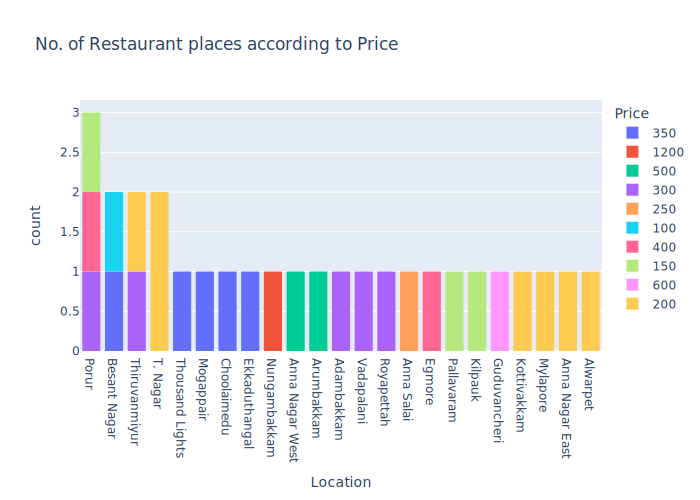

In [44]:
fig=px.histogram(rating_df,x='Location',color='Price',title='No. of  Restaurant places according to Price').update_xaxes(categoryorder='total descending')
fig.show()

In [45]:
nor_Ind_df=zomato_df.groupby('Location').agg({'Name of Restaurant':'count','Price':'mean'}).reset_index()
nor_Ind_df

,Location,Name of Restaurant,Price
0,Adyar,1,500.000000
1,Alwarpet,2,1150.000000
2,Ambattur,19,428.947368
3,Ambattur,1,300.000000
4,Aminijikarai,4,500.000000
...,...,...,...
143,Vepery,25,308.000000
144,Vettuvankeni,4,475.000000
145,Virugambakkam,36,408.333333
146,Washermenpet,52,366.346154


In [46]:
nor_Ind_df=zomato_df.groupby('Location').agg({'Name of Restaurant':'count','Price':'mean'}).rename(columns={'Name of Restaurant':'Count of Restaurant','Price':'Average Price'}).reset_index()
nor_Ind_df.head()

,Location,Count of Restaurant,Average Price
0,Adyar,1,500.000000
1,Alwarpet,2,1150.000000
2,Ambattur,19,428.947368
3,Ambattur,1,300.000000
4,Aminijikarai,4,500.000000


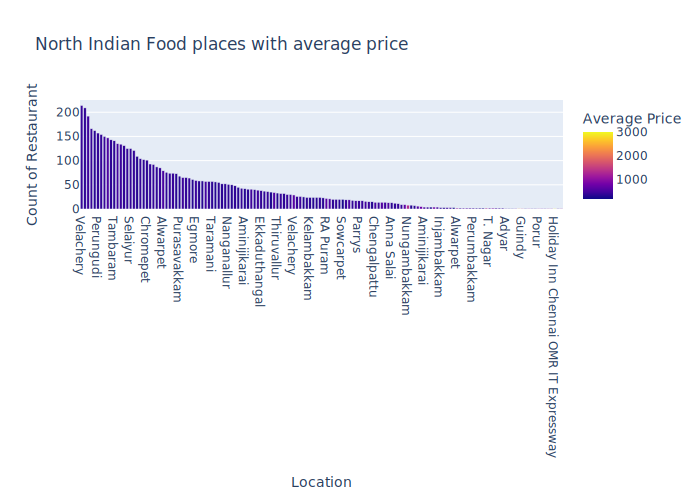

In [47]:
fig=px.bar(nor_Ind_df,x='Location',y='Count of Restaurant',color='Average Price',title='North Indian Food places with average price').update_xaxes(categoryorder='total descending')
fig.show()

In [49]:
Top_dish_df=zomato_df.groupby(['Top Dishes','Name of Restaurant'])['Price'].mean().reset_index()
Top_dish_df.head(10)

,Top Dishes,Name of Restaurant,Price
0,Aloo Paratha,The Delhi Dhaba,300.0
1,"Aloo Paratha, Rasgulla, Egg Bhurji, Roti",Gharka Khana Gharke Pass,300.0
2,"Aloo Paratha, Samosa, Palak Paneer",Shanthi Lakshmi Veg Restaurant,300.0
3,"Aloo Paratha, Vegetable Biryani, Panneer But...",ChappatiKings.com,350.0
4,"Aloo Patty, Sandwich, Salad, Chocolate Cookies",Subway,500.0
5,"Aloo Tikki, Naan, Roti, Momos, Paneer Tikk...",Ravi Mehra's Delhi Hotel,800.0
6,"Ambur Biryani, Chicken Lollipop, Naan, Toma...",Ambur Star Biryani,700.0
7,"American Chopsuey, Tandoori Chicken, Chop Su...",Anchor Restaurant,600.0
8,"Amritsari Kulcha, Chole, Paneer Bhurji, Las...",Balle Balle,300.0
9,Andhra Chicken Curry,Andhra Ruchulu,350.0


In [50]:
relation_df=zomato_df.groupby('Location')['Price'].mean().reset_index()
relation_df

,Location,Price
0,Adyar,500.000000
1,Alwarpet,1150.000000
2,Ambattur,428.947368
3,Ambattur,300.000000
4,Aminijikarai,500.000000
...,...,...
143,Vepery,308.000000
144,Vettuvankeni,475.000000
145,Virugambakkam,408.333333
146,Washermenpet,366.346154


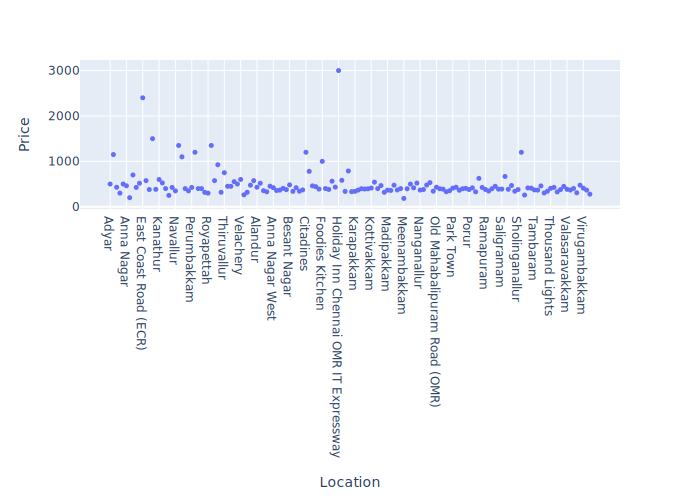

In [51]:
fig=px.scatter(relation_df,x='Location',y='Price').update_traces(marker_size=5)
fig.show()

In [52]:
max_price=zomato_df['Price'].max()
one_fourth_df=max_price/4
one_fourth_df

np.float64(750.0)

In [53]:
aff_rest_df=zomato_df[['Name of Restaurant','Location','Cuisine','Price','Features']]
aff_rest_df=aff_rest_df[aff_rest_df['Price']<=750]
aff_rest_df.sort_values(by='Price',ascending=False).inplace=True
aff_rest_df                      

,Name of Restaurant,Location,Cuisine,Price,Features
0,Yaa Mohaideen Briyani,Pallavaram,Biryani,500,"Home Delivery, Indoor Seating"
2,SS Hyderabad Biryani,Kodambakkam,"Biryani, North Indian, Chinese, Arabian",500,"Home Delivery, Indoor Seating"
3,KFC,Perambur,"Burger, Fast Food, Finger Food, Beverages",500,"Home Delivery, Free Parking, Card Upon Deliver..."
4,Tasty Kitchen,Perambur,"Chinese, Biryani, North Indian, Chettinad, ...",450,"Home Delivery, Indoor Seating"
5,Dine N Fun,Medavakkam,"South Indian, North Indian, Chinese",450,"Home Delivery, Indoor Seating"
...,...,...,...,...,...
11901,Dhabba On Wheels,Okkiyampet,North Indian,500,"Home Delivery, Indoor Seating"
11914,Sandwich Sisters,Velachery,Sandwich,200,"Home Delivery, Free Parking"
11953,The Sandwich Box,Navallur,"Sandwich, Fast Food, Beverages",300,"Home Delivery, Indoor Seating"
11959,The Shangai Story,Madipakkam,Chinese,350,Delivery Only


In [54]:
# Finding the highest delivery rated list of restaurants 

highest_rest_df=zomato_df[['Name of Restaurant','Location','Cuisine','Price','Features','Delivery Rating']]
highest_rest_df=highest_rest_df[highest_rest_df['Delivery Rating']>4.5]
highest_rest_df.sort_values(by='Delivery Rating',ascending=False).inplace=True
highest_rest_df

,Name of Restaurant,Location,Cuisine,Price,Features,Delivery Rating
92,Fruit Shop On Greams Road,Thousand Lights,"Beverages, Fast Food, Healthy Food, Juices",350,"Home Delivery, Vegetarian Only, Indoor Seating...",4.6
473,Dynasty,Nungambakkam,"Chinese, Seafood",1200,"Home Delivery, Full Bar Available, Valet Parki...",4.6
764,The Grand Sweets and Snacks - Amirtham Restaurant,Anna Nagar West,"Mithai, North Indian, South Indian",500,"Breakfast, Home Delivery, Vegetarian Only, Ind...",4.6
1274,Bite Me Cupcakes,Thiruvanmiyur,Desserts,300,"Home Delivery, Desserts and Bakes",4.6
1776,Casa Dolce,Mogappair,Bakery,350,"Home Delivery, Desserts and Bakes, Pre-Orderin...",4.6
1985,Arabian Plate,Adambakkam,"Arabian, Biryani",300,"Home Delivery, Indoor Seating",4.7
2011,Old Mercara,Anna Salai,"Ice Cream, Desserts",250,"Home Delivery, Desserts and Bakes",4.6
2151,Cane 4 U,Besant Nagar,Beverages,100,"Home Delivery, Indoor Seating",4.6
3158,Biryani In A Box,Egmore,"Biryani, Fast Food",400,Home Delivery,4.6
3301,Mo Thickshake And Snackers,Vadapalani,Beverages,300,Home Delivery,4.7


In [55]:
merge_df=pd.merge(aff_rest_df,highest_rest_df,how='inner',on=['Name of Restaurant','Location'])
merge_df

,Name of Restaurant,Location,Cuisine_x,Price_x,Features_x,Cuisine_y,Price_y,Features_y,Delivery Rating
0,Fruit Shop On Greams Road,Thousand Lights,"Beverages, Fast Food, Healthy Food, Juices",350,"Home Delivery, Vegetarian Only, Indoor Seating...","Beverages, Fast Food, Healthy Food, Juices",350,"Home Delivery, Vegetarian Only, Indoor Seating...",4.6
1,The Grand Sweets and Snacks - Amirtham Restaurant,Anna Nagar West,"Mithai, North Indian, South Indian",500,"Breakfast, Home Delivery, Vegetarian Only, Ind...","Mithai, North Indian, South Indian",500,"Breakfast, Home Delivery, Vegetarian Only, Ind...",4.6
2,Bite Me Cupcakes,Thiruvanmiyur,Desserts,300,"Home Delivery, Desserts and Bakes",Desserts,300,"Home Delivery, Desserts and Bakes",4.6
3,Casa Dolce,Mogappair,Bakery,350,"Home Delivery, Desserts and Bakes, Pre-Orderin...",Bakery,350,"Home Delivery, Desserts and Bakes, Pre-Orderin...",4.6
4,Arabian Plate,Adambakkam,"Arabian, Biryani",300,"Home Delivery, Indoor Seating","Arabian, Biryani",300,"Home Delivery, Indoor Seating",4.7
5,Old Mercara,Anna Salai,"Ice Cream, Desserts",250,"Home Delivery, Desserts and Bakes","Ice Cream, Desserts",250,"Home Delivery, Desserts and Bakes",4.6
6,Cane 4 U,Besant Nagar,Beverages,100,"Home Delivery, Indoor Seating",Beverages,100,"Home Delivery, Indoor Seating",4.6
7,Biryani In A Box,Egmore,"Biryani, Fast Food",400,Home Delivery,"Biryani, Fast Food",400,Home Delivery,4.6
8,Mo Thickshake And Snackers,Vadapalani,Beverages,300,Home Delivery,Beverages,300,Home Delivery,4.7
9,Mumbai Kulfi,Pallavaram,Desserts,150,"Home Delivery, Free Parking, Outdoor Seating, ...",Desserts,150,"Home Delivery, Free Parking, Outdoor Seating, ...",4.7


In [57]:
Highest_rest_df=merge_df[['Name of Restaurant','Location','Cuisine_x','Price_x','Features_x','Delivery Rating']]
Highest_rest_df=Highest_rest_df.rename(columns={'Name of Restaurant':'Name of Restaurant','Location':'Location','Cuisine_x':'Cuisine','Price_x':'Price','Features_x':'Features','Delivery Rating':'Rating'})
Highest_rest_df

,Name of Restaurant,Location,Cuisine,Price,Features,Rating
0,Fruit Shop On Greams Road,Thousand Lights,"Beverages, Fast Food, Healthy Food, Juices",350,"Home Delivery, Vegetarian Only, Indoor Seating...",4.6
1,The Grand Sweets and Snacks - Amirtham Restaurant,Anna Nagar West,"Mithai, North Indian, South Indian",500,"Breakfast, Home Delivery, Vegetarian Only, Ind...",4.6
2,Bite Me Cupcakes,Thiruvanmiyur,Desserts,300,"Home Delivery, Desserts and Bakes",4.6
3,Casa Dolce,Mogappair,Bakery,350,"Home Delivery, Desserts and Bakes, Pre-Orderin...",4.6
4,Arabian Plate,Adambakkam,"Arabian, Biryani",300,"Home Delivery, Indoor Seating",4.7
5,Old Mercara,Anna Salai,"Ice Cream, Desserts",250,"Home Delivery, Desserts and Bakes",4.6
6,Cane 4 U,Besant Nagar,Beverages,100,"Home Delivery, Indoor Seating",4.6
7,Biryani In A Box,Egmore,"Biryani, Fast Food",400,Home Delivery,4.6
8,Mo Thickshake And Snackers,Vadapalani,Beverages,300,Home Delivery,4.7
9,Mumbai Kulfi,Pallavaram,Desserts,150,"Home Delivery, Free Parking, Outdoor Seating, ...",4.7
